# Analyse quantitative — Dataset002_Heart

Métriques calculées sur les 20 cas de segmentation de l'atrium gauche (nnU-Net, 5-fold cross-validation).

## 1 : Imports etchemins

In [15]:
import os
import json
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
from scipy.ndimage import binary_dilation
from skimage.measure import label, regionprops, marching_cubes


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [16]:
NOTEBOOK_DIR  = Path(os.getcwd()).resolve()
DATASET_DIR   = NOTEBOOK_DIR.parent
RESULTS_BASE  = DATASET_DIR / 'result' / 'nnUnet_results' / 'Dataset002_Heart' / 'nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres'
DATA_BASE     = DATASET_DIR / 'data' / 'Task02_Heart'
POSTPROC_DIR  = RESULTS_BASE / 'crossval_results_folds_0_1_2_3_4' / 'postprocessed'
SUMMARY_PATH  = POSTPROC_DIR / 'summary.json'

for name, path in [('DATA_BASE', DATA_BASE), ('POSTPROC_DIR', POSTPROC_DIR), ('SUMMARY_PATH', SUMMARY_PATH)]:
    status = 'OK' if path.exists() else 'NOT FOUND'
    print(f'  {name:<14}: {path}  [{status}]')

  DATA_BASE     : C:\Users\Walid\Documents\GitHub\IFT-3710-Projet\data\Task02_Heart  [OK]
  POSTPROC_DIR  : C:\Users\Walid\Documents\GitHub\IFT-3710-Projet\result\nnUnet_results\Dataset002_Heart\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\crossval_results_folds_0_1_2_3_4\postprocessed  [OK]
  SUMMARY_PATH  : C:\Users\Walid\Documents\GitHub\IFT-3710-Projet\result\nnUnet_results\Dataset002_Heart\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\crossval_results_folds_0_1_2_3_4\postprocessed\summary.json  [OK]


## 2 : Chargement de `summary.json`

In [17]:
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

case_ids = [Path(c['prediction_file']).stem for c in summary['metric_per_case']]

# dict pour retrouver le dice d'un cas rapidement
dice_lookup = {
    Path(c['prediction_file']).stem: c['metrics']['1']['Dice']
    for c in summary['metric_per_case']
}

print(f'{len(case_ids)} cas trouvés : {sorted(case_ids)}')

20 cas trouvés : ['la_003.nii', 'la_004.nii', 'la_005.nii', 'la_007.nii', 'la_009.nii', 'la_010.nii', 'la_011.nii', 'la_014.nii', 'la_016.nii', 'la_017.nii', 'la_018.nii', 'la_019.nii', 'la_020.nii', 'la_021.nii', 'la_022.nii', 'la_023.nii', 'la_024.nii', 'la_026.nii', 'la_029.nii', 'la_030.nii']


## 3 : Calcul des métriques par cas


In [18]:
records = []

for case_id in sorted(case_ids):
    gt_path   = DATA_BASE / 'labelsTr' / f'{case_id}.gz'
    pred_path = POSTPROC_DIR / f'{case_id}.gz'
    img_0000  = DATA_BASE / 'imagesTr' / f'{case_id}_0000.nii.gz'
    img_plain = DATA_BASE / 'imagesTr' / f'{case_id}.gz'
    img_path  = img_0000 if img_0000.exists() else img_plain

    gt_nib   = nib.load(gt_path)
    pred_nib = nib.load(pred_path)
    img_nib  = nib.load(img_path)

    gt_data   = gt_nib.get_fdata().astype(np.uint8)
    pred_data = pred_nib.get_fdata().astype(np.uint8)
    img_data  = img_nib.get_fdata()

    spacing = gt_nib.header.get_zooms()[:3]
    voxel_vol_mm3 = float(spacing[0]) * float(spacing[1]) * float(spacing[2])

    dice = dice_lookup[case_id]

    # volumes en mL
    gt_vox   = int((gt_data == 1).sum())
    pred_vox = int((pred_data == 1).sum())
    gt_vol_mL   = gt_vox   * voxel_vol_mm3 / 1000.0
    pred_vol_mL = pred_vox * voxel_vol_mm3 / 1000.0
    vol_error_mL = pred_vol_mL - gt_vol_mL
    over_under  = 'over' if pred_vol_mL > gt_vol_mL else 'under'

    # TP / FP / FN
    TP = int(((pred_data == 1) & (gt_data == 1)).sum())
    FP = int(((pred_data == 1) & (gt_data == 0)).sum())
    FN = int(((pred_data == 0) & (gt_data == 1)).sum())
    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 0.0
    fn_ratio = FN / gt_vox    if gt_vox    > 0 else 0.0

    # forme : élongation et sphéricité depuis le masque GT
    gt_labeled = label(gt_data)
    props = regionprops(gt_labeled)
    if props:
        bb = props[0].bbox
        bb_sizes = [s for s in [bb[3]-bb[0], bb[4]-bb[1], bb[5]-bb[2]] if s > 0]
        elongation = max(bb_sizes) / min(bb_sizes) if bb_sizes else float('nan')
        try:
            verts, faces, _, _ = marching_cubes(gt_data, level=0.5, spacing=tuple(float(x) for x in spacing))
            surf_area = sum(
                0.5 * float(np.linalg.norm(np.cross(verts[f[1]]-verts[f[0]], verts[f[2]]-verts[f[0]])))
                for f in faces
            )
            vol_mm3 = gt_vox * voxel_vol_mm3
            sphericity = (np.pi**(1/3) * (6*vol_mm3)**(2/3)) / surf_area if surf_area > 0 else float('nan')
        except Exception:
            sphericity = float('nan')
    else:
        elongation = float('nan')
        sphericity = float('nan')

    # contraste Michelson : atrium vs tissu voisin immédiat
    atrium_mask  = gt_data == 1
    dilated      = binary_dilation(gt_data, iterations=3)
    voisins_mask = dilated & (gt_data == 0)
    if atrium_mask.any() and voisins_mask.any():
        med_a = float(np.median(img_data[atrium_mask]))
        med_v = float(np.median(img_data[voisins_mask]))
        denom = med_a + med_v
        contrast = (med_a - med_v) / denom if denom != 0 else float('nan')
    else:
        contrast = float('nan')

    if np.isnan(contrast):
        contrast_cat = 'N/A'
    elif contrast >= 0.25:
        contrast_cat = 'Haut'
    elif contrast >= 0.15:
        contrast_cat = 'Moyen'
    else:
        contrast_cat = 'Bas'

    print(f'Processing {case_id}...  Dice={dice:.3f}, Contrast={contrast:.3f}, Sphericity={sphericity:.3f}')

    records.append({
        'case_id': case_id, 'dice': dice,
        'gt_vol_mL': gt_vol_mL, 'pred_vol_mL': pred_vol_mL, 'vol_error_mL': vol_error_mL, 'over_under': over_under,
        'fp_ratio': fp_ratio, 'fn_ratio': fn_ratio,
        'elongation': elongation, 'sphericity': sphericity, 'contrast': contrast, 'contrast_cat': contrast_cat,
        'sp_x': float(spacing[0]), 'sp_y': float(spacing[1]), 'sp_z': float(spacing[2]),
        'voxel_vol_mm3': voxel_vol_mm3,
        'anisotropie': float(max(spacing) / min(spacing)),
    })

Processing la_003.nii...  Dice=0.953, Contrast=0.276, Sphericity=0.645
Processing la_004.nii...  Dice=0.933, Contrast=0.153, Sphericity=0.670
Processing la_005.nii...  Dice=0.931, Contrast=0.204, Sphericity=0.686
Processing la_007.nii...  Dice=0.929, Contrast=0.220, Sphericity=0.653
Processing la_009.nii...  Dice=0.879, Contrast=0.153, Sphericity=0.621
Processing la_010.nii...  Dice=0.918, Contrast=0.194, Sphericity=0.671
Processing la_011.nii...  Dice=0.939, Contrast=0.137, Sphericity=0.688
Processing la_014.nii...  Dice=0.935, Contrast=0.233, Sphericity=0.738
Processing la_016.nii...  Dice=0.949, Contrast=0.184, Sphericity=0.715
Processing la_017.nii...  Dice=0.936, Contrast=0.287, Sphericity=0.666
Processing la_018.nii...  Dice=0.922, Contrast=0.217, Sphericity=0.629
Processing la_019.nii...  Dice=0.869, Contrast=0.184, Sphericity=0.662
Processing la_020.nii...  Dice=0.896, Contrast=0.266, Sphericity=0.660
Processing la_021.nii...  Dice=0.936, Contrast=0.207, Sphericity=0.642
Proces

## 4 : Création du DF

In [19]:
df = pd.DataFrame(records).sort_values('dice', ascending=True).reset_index(drop=True)
FLOAT_COLS = ['dice', 'gt_vol_mL', 'pred_vol_mL', 'vol_error_mL', 'fp_ratio', 'fn_ratio', 'elongation', 'sphericity', 'contrast', 'anisotropie']
print(f'{len(df)} cas traités.')
print(f'Dice: min={df["dice"].min():.3f}, max={df["dice"].max():.3f}, mean={df["dice"].mean():.3f}')
print(f'Volume (GT): min={df["gt_vol_mL"].min():.1f} mL, max={df["gt_vol_mL"].max():.1f} mL')


20 cas traités.
Dice: min=0.869, max=0.953, mean=0.927
Volume (GT): min=68.6 mL, max=145.9 mL


## 5 : Tableau 

In [20]:
def color_by_dice(row):
    d = row['dice']
    if d < 0.90:   bg = 'background-color: #ffcccc'
    elif d < 0.93: bg = 'background-color: #ffe0b2'
    else:          bg = 'background-color: #c8e6c9'
    return [bg] * len(row)


In [21]:
DISPLAY_COLS = ['case_id', 'dice', 'gt_vol_mL', 'pred_vol_mL', 'vol_error_mL', 'over_under',
                'fp_ratio', 'fn_ratio', 'elongation', 'sphericity', 'contrast', 'anisotropie']

styled = (
    df[DISPLAY_COLS].style
      .apply(color_by_dice, axis=1)
      .format({col: '{:.3f}' for col in FLOAT_COLS})
      .set_caption('Métriques quantitatives par cas — trié par Dice croissant')
      .set_table_styles([{
          'selector': 'caption',
          'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '6px')]
      }])
)
display(styled)


,case_id,dice,gt_vol_mL,pred_vol_mL,vol_error_mL,over_under,fp_ratio,fn_ratio,elongation,sphericity,contrast,anisotropie
0,la_019.nii,0.869,116.191,91.375,-24.816,under,0.013,0.224,1.574,0.662,0.184,1.096
1,la_009.nii,0.879,100.847,98.578,-2.269,under,0.111,0.131,1.646,0.621,0.153,1.096
2,la_020.nii,0.896,68.586,57.506,-11.080,under,0.018,0.176,1.842,0.660,0.266,1.096
3,la_010.nii,0.918,80.526,86.822,6.296,over,0.116,0.046,1.475,0.671,0.194,1.096
4,la_018.nii,0.922,86.338,76.581,-9.757,under,0.019,0.130,1.744,0.629,0.217,1.096
5,la_029.nii,0.927,69.799,71.553,1.753,over,0.085,0.062,1.765,0.647,0.235,1.096
6,la_007.nii,0.929,118.685,108.380,-10.305,under,0.027,0.111,1.810,0.653,0.220,1.096
7,la_024.nii,0.930,99.518,104.775,5.257,over,0.094,0.046,2.121,0.672,0.239,1.096
8,la_026.nii,0.930,115.305,123.735,8.430,over,0.101,0.036,2.147,0.690,0.197,1.096
9,la_005.nii,0.931,124.608,115.403,-9.205,under,0.032,0.103,1.762,0.686,0.204,1.096


## 6 : Dice vs Volume GT (coloré par Sphéricité)

Scatter plot : chaque point est un cas. On veut voir si les petits atriums ou les formes atypiques donnent un Dice plus bas.

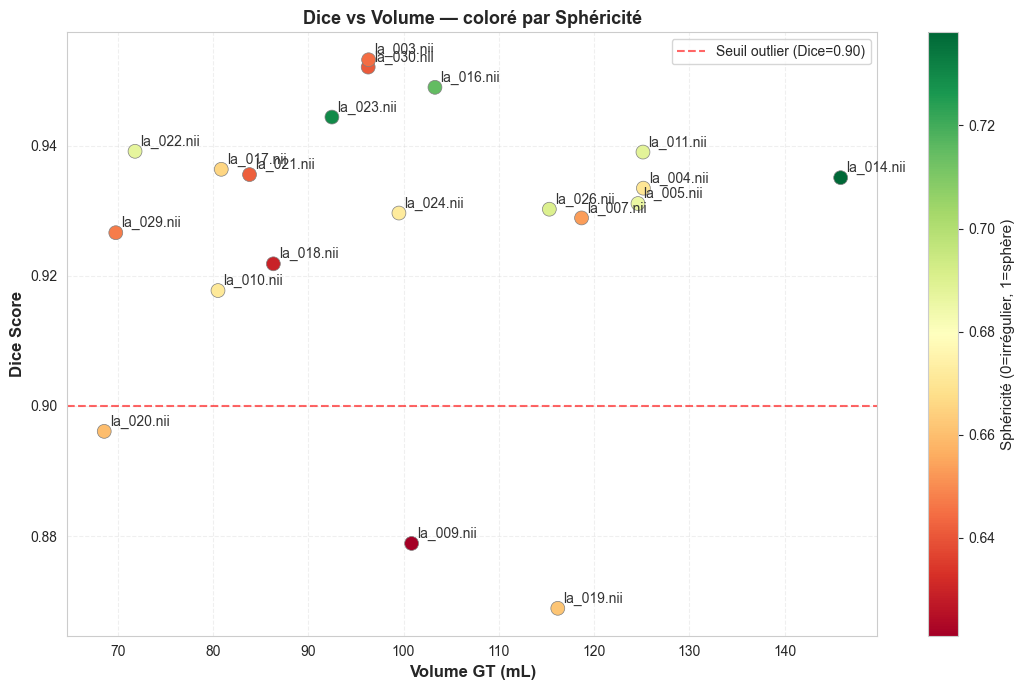


Corrélations :
  Volume ↔ Dice : r = +0.040
  Sphéricité ↔ Dice : r = +0.359


In [22]:
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter plot: X=volume, Y=dice, couleur=sphericity
cmap = plt.get_cmap('RdYlGn')
norm = Normalize(vmin=df['sphericity'].min(), vmax=df['sphericity'].max())
colors = [cmap(norm(s)) for s in df['sphericity']]

scatter = ax.scatter(
    df['gt_vol_mL'], df['dice'],
    c=df['sphericity'], cmap='RdYlGn', s=100, edgecolors='grey', linewidth=0.5, zorder=3,
    vmin=df['sphericity'].min(), vmax=df['sphericity'].max()
)

# Annoter chaque point avec le case_id
for _, row in df.iterrows():
    ax.annotate(
        row['case_id'],
        xy=(row['gt_vol_mL'], row['dice']),
        xytext=(4, 4), textcoords='offset points',
        fontsize=10, color='#333333', weight='normal'
    )

# Seuil outlier
ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Seuil outlier (Dice=0.90)')

ax.set_xlabel('Volume GT (mL)', fontsize=12, weight='bold')
ax.set_ylabel('Dice Score', fontsize=12, weight='bold')
ax.set_title('Dice vs Volume — coloré par Sphéricité', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

cbar = fig.colorbar(scatter, ax=ax, label='Sphéricité')
cbar.set_label('Sphéricité (0=irrégulier, 1=sphère)', fontsize=11)

plt.tight_layout()
plt.show()

# Corrélations
corr_vol_dice = df['gt_vol_mL'].corr(df['dice'])
corr_sph_dice = df['sphericity'].corr(df['dice'])
print(f'\nCorrélations :')
print(f'  Volume ↔ Dice : r = {corr_vol_dice:+.3f}')
print(f'  Sphéricité ↔ Dice : r = {corr_sph_dice:+.3f}')


## 7 : Dice par catégorie Over/Under

Dot plot : distribution complète du Dice selon si le modèle a sur- ou sous-segmenté. Chaque point = un cas, la barre = la médiane.

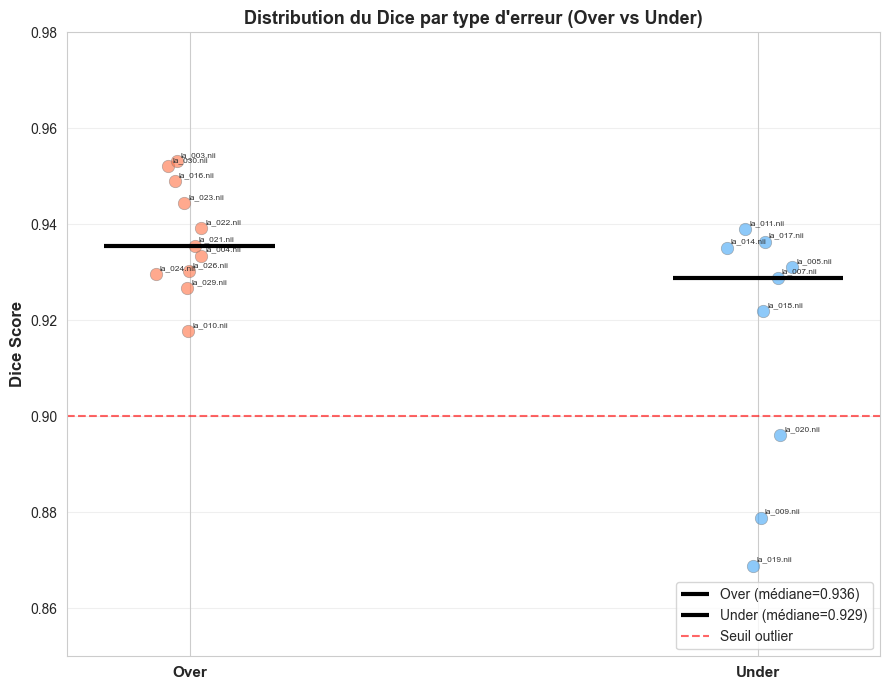


Statistiques par groupe (Over/Under) :

OVER:
  n=11, mean=0.937, median=0.936, std=0.011
  Outliers (<0.90): 0

UNDER:
  n=9, mean=0.915, median=0.929, std=0.027
  Outliers (<0.90): 3


In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

# Groupes
groups = df['over_under'].unique()
group_order = sorted(groups)

x_positions = {g: i for i, g in enumerate(group_order)}
colors_group = {'over': '#ff7043', 'under': '#42a5f5'}

# Strip plot: chaque point est un cas
for group in group_order:
    subset = df[df['over_under'] == group]
    x_jitter = [x_positions[group] + np.random.normal(0, 0.04) for _ in range(len(subset))]
    ax.scatter(
        x_jitter, subset['dice'],
        s=80, alpha=0.6, color=colors_group[group],
        edgecolors='grey', linewidth=0.5, zorder=3
    )
    # Annoter
    for i, (j, d, cid) in enumerate(zip(x_jitter, subset['dice'], subset['case_id'])):
        ax.annotate(cid, xy=(j, d), xytext=(3, 3), textcoords='offset points',
                    fontsize=6, color='#333333')

# Médiane par groupe
for group in group_order:
    subset = df[df['over_under'] == group]
    med = subset['dice'].median()
    x = x_positions[group]
    ax.hlines(med, x - 0.15, x + 0.15, colors='black', linewidth=3, zorder=5, label=f'{group.capitalize()} (médiane={med:.3f})')

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels([g.capitalize() for g in group_order], fontsize=11, weight='bold')
ax.set_ylabel('Dice Score', fontsize=12, weight='bold')
ax.set_title('Distribution du Dice par type d\'erreur (Over vs Under)', fontsize=13, weight='bold')
ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Seuil outlier')
ax.set_ylim(0.85, 0.98)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

# Statistiques par groupe
print('\nStatistiques par groupe (Over/Under) :')
for group in group_order:
    subset = df[df['over_under'] == group]
    print(f'\n{group.upper()}:')
    print(f'  n={len(subset)}, mean={subset["dice"].mean():.3f}, median={subset["dice"].median():.3f}, std={subset["dice"].std():.3f}')
    print(f'  Outliers (<0.90): {len(subset[subset["dice"] < 0.90])}')


## 8 : Distribution du Dice selon le Contraste (Raincloud)

Violin + strip plot groupés par niveau de contraste (Bas / Moyen / Haut). On cherche à savoir si un contraste faible dégrade systématiquement le Dice.

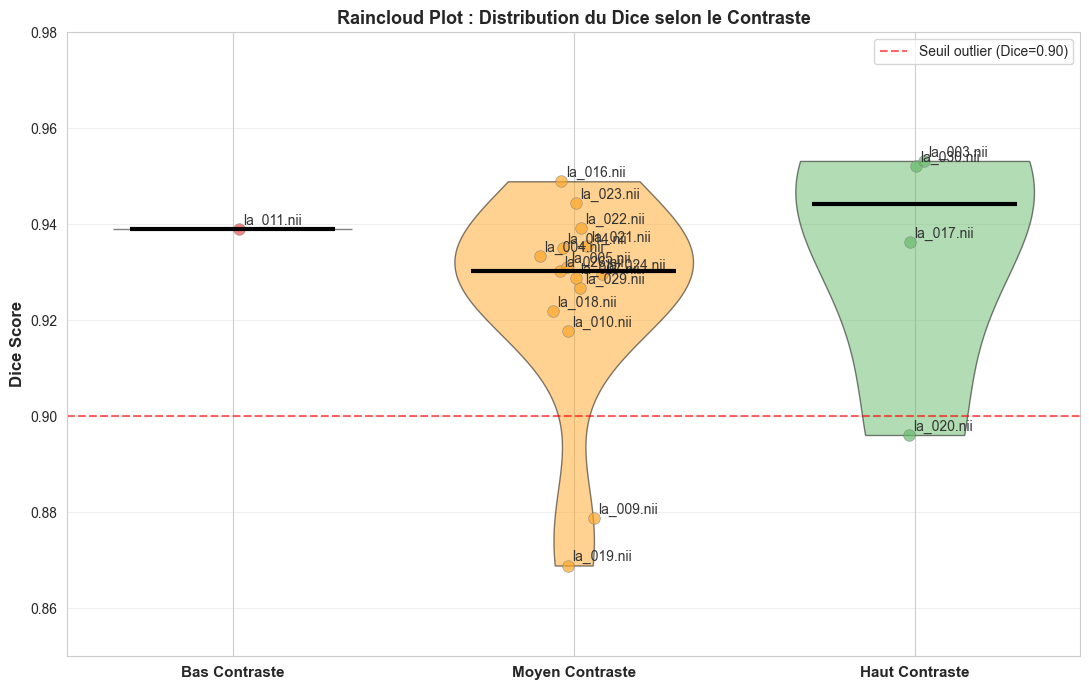


Statistiques par niveau de Contraste :

BAS CONTRASTE:
  n=1, mean=0.939, median=0.939, std=nan
  Outliers (<0.90): 0
  Contraste médian: 0.137

MOYEN CONTRASTE:
  n=15, mean=0.925, median=0.930, std=0.022
  Outliers (<0.90): 2
  Contraste médian: 0.207

HAUT CONTRASTE:
  n=4, mean=0.934, median=0.944, std=0.027
  Outliers (<0.90): 1
  Contraste médian: 0.275


In [24]:
fig, ax = plt.subplots(figsize=(11, 7))

# Tri des catégories pour l'ordre
contrast_order = ['Bas', 'Moyen', 'Haut']
df_plot = df[df['contrast_cat'].isin(contrast_order)].copy()

# Couleurs
colors_contrast = {'Bas': '#ef5350', 'Moyen': '#ffa726', 'Haut': '#66bb6a'}

# Raincloud : violin + strip
for i, cat in enumerate(contrast_order):
    subset = df_plot[df_plot['contrast_cat'] == cat]['dice'].values
    if len(subset) == 0:
        continue

    # Violin
    parts = ax.violinplot([subset], positions=[i], widths=0.7,
                          showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colors_contrast[cat])
        pc.set_alpha(0.5)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)

    # Strip plot (points jitter)
    x_jitter = [i + np.random.normal(0, 0.04) for _ in range(len(subset))]
    ax.scatter(x_jitter, subset, s=70, alpha=0.7, color=colors_contrast[cat],
              edgecolors='grey', linewidth=0.5, zorder=3)

    # Annoter chaque point avec case_id
    for j, (xj, val, cid) in enumerate(zip(x_jitter, subset, df_plot[df_plot['contrast_cat'] == cat]['case_id'])):
        ax.annotate(cid, xy=(xj, val), xytext=(3, 3), textcoords='offset points',
                   fontsize=10, color='#333333')

    # Médiane
    med = np.median(subset)
    ax.hlines(med, i - 0.3, i + 0.3, colors='black', linewidth=3, zorder=5)

ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Seuil outlier (Dice=0.90)')
ax.set_xticks(range(len(contrast_order)))
ax.set_xticklabels([f'{cat} Contraste' for cat in contrast_order], fontsize=11, weight='bold')
ax.set_ylabel('Dice Score', fontsize=12, weight='bold')
ax.set_title('Raincloud Plot : Distribution du Dice selon le Contraste', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10)
ax.set_ylim(0.85, 0.98)

plt.tight_layout()
plt.show()

# Statistiques
print('\nStatistiques par niveau de Contraste :')
for cat in contrast_order:
    subset = df_plot[df_plot['contrast_cat'] == cat]
    if len(subset) > 0:
        print(f'\n{cat.upper()} CONTRASTE:')
        print(f'  n={len(subset)}, mean={subset["dice"].mean():.3f}, median={subset["dice"].median():.3f}, std={subset["dice"].std():.3f}')
        print(f'  Outliers (<0.90): {len(subset[subset["dice"] < 0.90])}')
        print(f'  Contraste médian: {subset["contrast"].median():.3f}')


## 9 : SCATTER PLOT : Elongation vs Dice

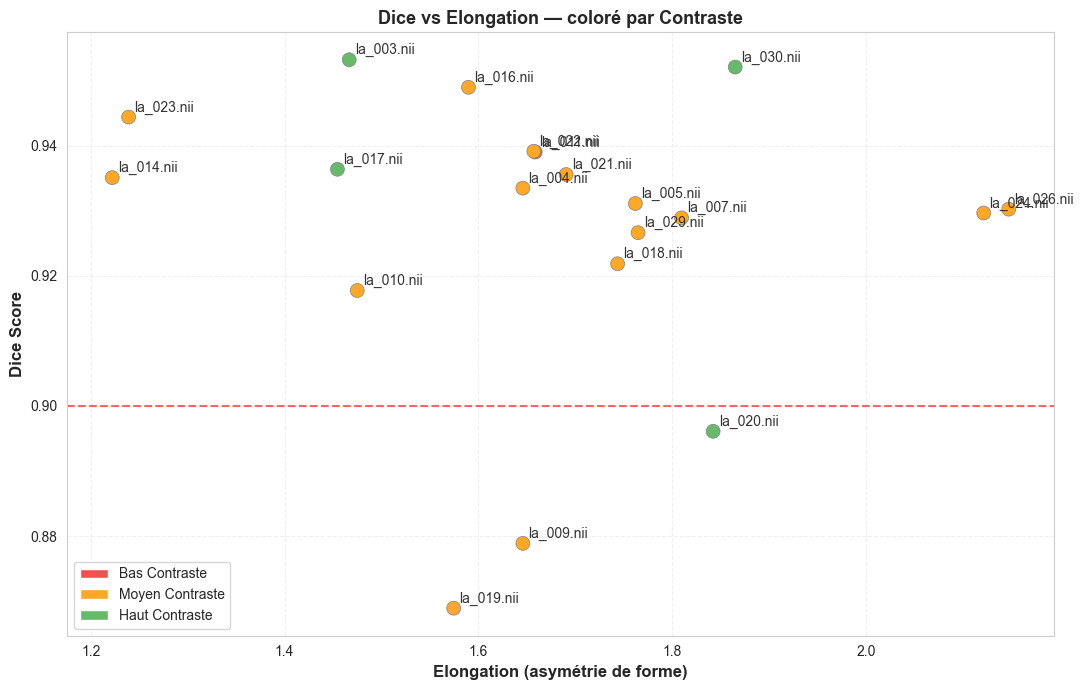

Corrélation Elongation ↔ Dice : r = -0.094


In [25]:
fig, ax = plt.subplots(figsize=(11, 7))

# Couleur par contraste
colors_cat = {'Bas': '#ef5350', 'Moyen': '#ffa726', 'Haut': '#66bb6a', 'N/A': '#bdbdbd'}
colors = [colors_cat.get(c, '#bdbdbd') for c in df['contrast_cat']]

scatter = ax.scatter(
    df['elongation'], df['dice'],
    c=colors, s=100, edgecolors='grey', linewidth=0.5, zorder=3
)

# Annoter
for _, row in df.iterrows():
    ax.annotate(row['case_id'], xy=(row['elongation'], row['dice']),
               xytext=(4, 4), textcoords='offset points', fontsize=10, color='#333333')

ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Seuil outlier')
ax.set_xlabel('Elongation (asymétrie de forme)', fontsize=12, weight='bold')
ax.set_ylabel('Dice Score', fontsize=12, weight='bold')
ax.set_title('Dice vs Elongation — coloré par Contraste', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Légende
legend_handles = [mpatches.Patch(facecolor=colors_cat[c], label=f'{c} Contraste') for c in contrast_order]
ax.legend(handles=legend_handles, fontsize=10, loc='lower left')

plt.tight_layout()
plt.show()

corr_elong = df['elongation'].corr(df['dice'])
print(f'Corrélation Elongation ↔ Dice : r = {corr_elong:+.3f}')


## 10 : SCATTER PLOT : FP_ratio vs FN_ratio (coloré par Dice)

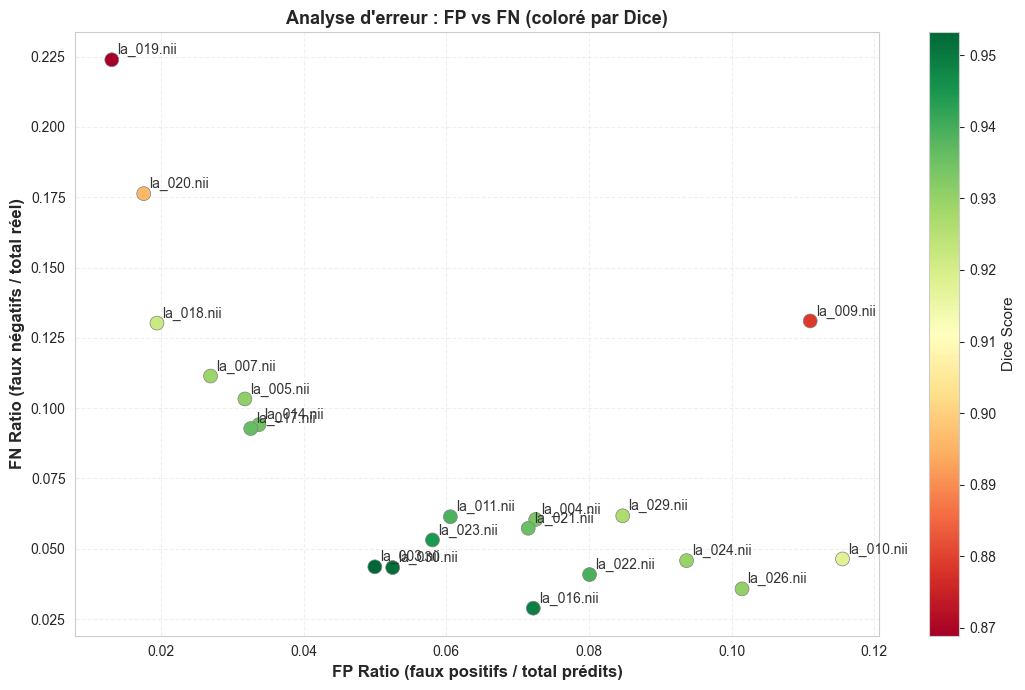


Corrélations :
  FP_ratio ↔ Dice : r = +0.078
  FN_ratio ↔ Dice : r = -0.829


In [26]:
fig, ax = plt.subplots(figsize=(11, 7))

# Couleur par Dice
cmap_dice = plt.get_cmap('RdYlGn')
norm_dice = Normalize(vmin=df['dice'].min(), vmax=df['dice'].max())

scatter = ax.scatter(
    df['fp_ratio'], df['fn_ratio'],
    c=df['dice'], cmap='RdYlGn', s=100, edgecolors='grey', linewidth=0.5, zorder=3,
    vmin=df['dice'].min(), vmax=df['dice'].max()
)

# Annoter
for _, row in df.iterrows():
    ax.annotate(row['case_id'], xy=(row['fp_ratio'], row['fn_ratio']),
               xytext=(4, 4), textcoords='offset points', fontsize=10, color='#333333')

ax.set_xlabel('FP Ratio (faux positifs / total prédits)', fontsize=12, weight='bold')
ax.set_ylabel('FN Ratio (faux négatifs / total réel)', fontsize=12, weight='bold')
ax.set_title('Analyse d\'erreur : FP vs FN (coloré par Dice)', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Dice Score', fontsize=11)

plt.tight_layout()
plt.show()

# Corrélations
corr_fp = df['fp_ratio'].corr(df['dice'])
corr_fn = df['fn_ratio'].corr(df['dice'])
print(f'\nCorrélations :')
print(f'  FP_ratio ↔ Dice : r = {corr_fp:+.3f}')
print(f'  FN_ratio ↔ Dice : r = {corr_fn:+.3f}')


## 11 — Résumé des cas outliers (Dice < 0.90)

In [27]:
outliers = df[df['dice'] < 0.90].reset_index(drop=True)

if len(outliers) == 0:
    print('Aucun cas avec Dice < 0.90.')
else:
    print(f'{len(outliers)} cas outlier(s) détecté(s) :\n')
    display(
        outliers[['case_id', 'dice', 'gt_vol_mL', 'over_under', 'fp_ratio', 'fn_ratio', 'elongation', 'sphericity', 'contrast', 'anisotropie']].style
               .format({col: '{:.3f}' for col in FLOAT_COLS})
               .set_caption('Cas outliers — Dice < 0.90')
               .map(lambda _: 'background-color: #ffcccc')
    )

3 cas outlier(s) détecté(s) :



,case_id,dice,gt_vol_mL,over_under,fp_ratio,fn_ratio,elongation,sphericity,contrast,anisotropie
0,la_019.nii,0.869,116.191,under,0.013,0.224,1.574,0.662,0.184,1.096
1,la_009.nii,0.879,100.847,under,0.111,0.131,1.646,0.621,0.153,1.096
2,la_020.nii,0.896,68.586,under,0.018,0.176,1.842,0.660,0.266,1.096
